In [1]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, accuracy_score
)
from sklearn.calibration import calibration_curve

In [2]:
# Load balanced training and test sets
X_train_res, y_train_res = joblib.load("X_train_balanced.pkl")
X_test, y_test           = joblib.load("X_test_balanced.pkl")
class_names              = joblib.load("class_names.pkl")

In [3]:
# Train Gradient Boosting classifier
gb_model = GradientBoostingClassifier(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
  
gb_model.fit(X_train_res, y_train_res)

# Save model
joblib.dump(gb_model, "gradient_boosting.pkl")
print("✅ Gradient Boosting model trained and saved as gradient_boosting.pkl")

✅ Gradient Boosting model trained and saved as gradient_boosting.pkl


Explanation:
We configure Gradient Boosting with 50 trees, moderate depth, and learning rate. The model is saved for reuse.


Confusion Matrix

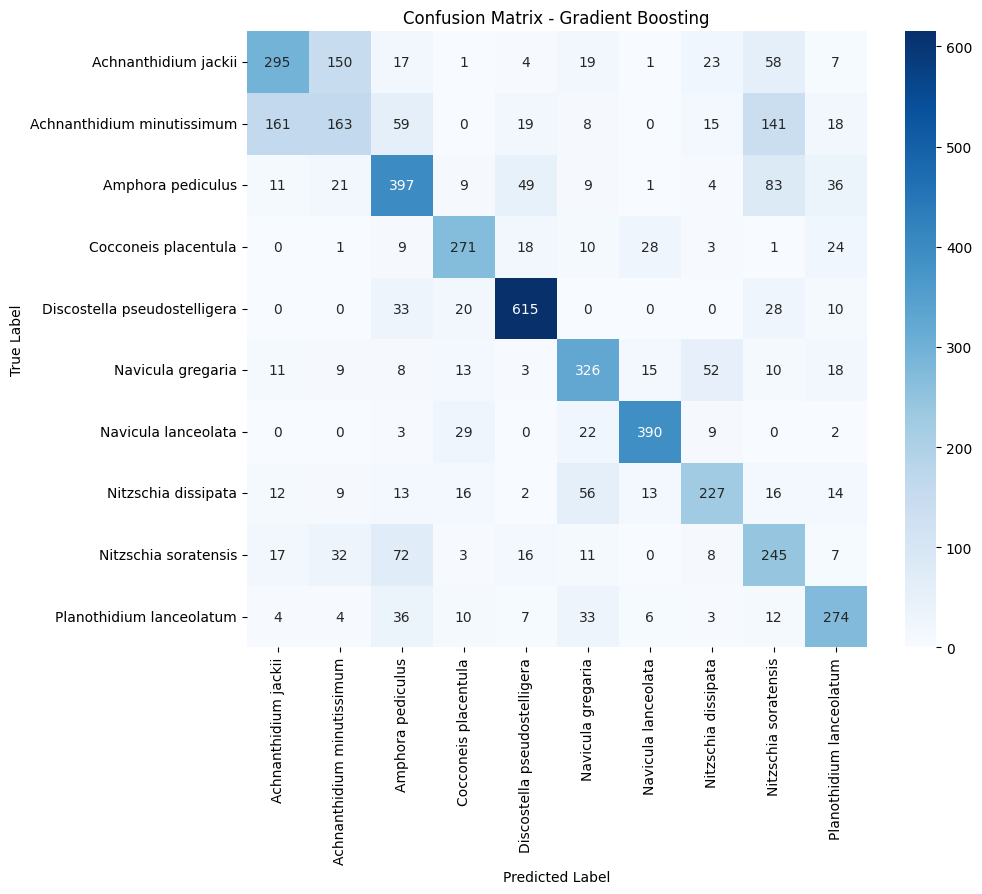

In [11]:
y_pred = gb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

Explanation:
Shows per-class predictions vs true labels, highlighting misclassifications


ROC Curve (One-vs-Rest Example)

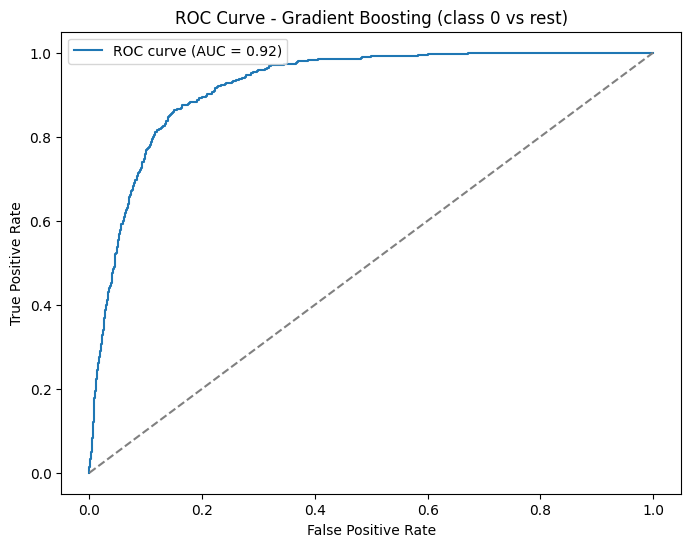

In [5]:
y_prob = gb_model.predict_proba(X_test)
fpr, tpr, _ = roc_curve((y_test == 0).astype(int), y_prob[:,0], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting (class 0 vs rest)")
plt.legend()
plt.show()

Explanation:
For multi-class, ROC is plotted one-vs-rest. Here we show class 0 vs all others as an example.


Precision-Recall Curve

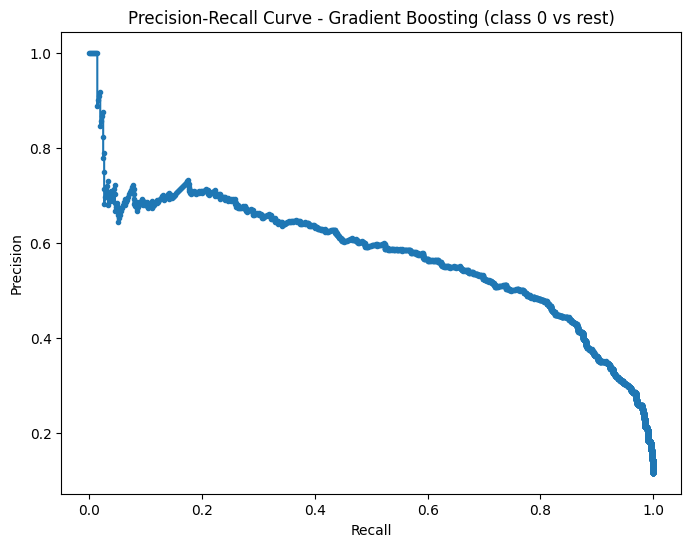

In [6]:
precision, recall, thresholds = precision_recall_curve((y_test == 0).astype(int), y_prob[:,0])

plt.figure(figsize=(8,6))
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Gradient Boosting (class 0 vs rest)")
plt.show()

Explanation:
Shows trade-off between precision and recall for one class


Confidence Distribution

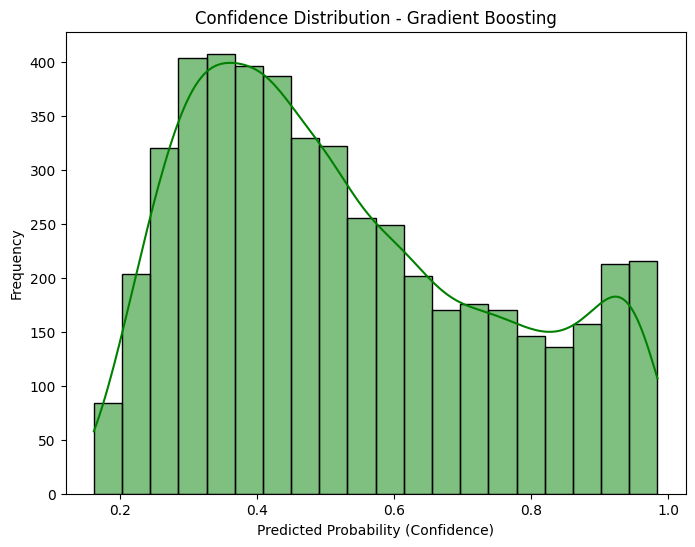

In [7]:
plt.figure(figsize=(8,6))
sns.histplot(np.max(y_prob, axis=1), bins=20, kde=True, color="green")
plt.xlabel("Predicted Probability (Confidence)")
plt.ylabel("Frequency")
plt.title("Confidence Distribution - Gradient Boosting")
plt.show()

Explanation:
Shows how confident the model is in its predictions


Class-wise Accuracy

C:\Users\Yaswanth\AppData\Local\Temp\ipykernel_25352\164645744.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_acc, palette="viridis")


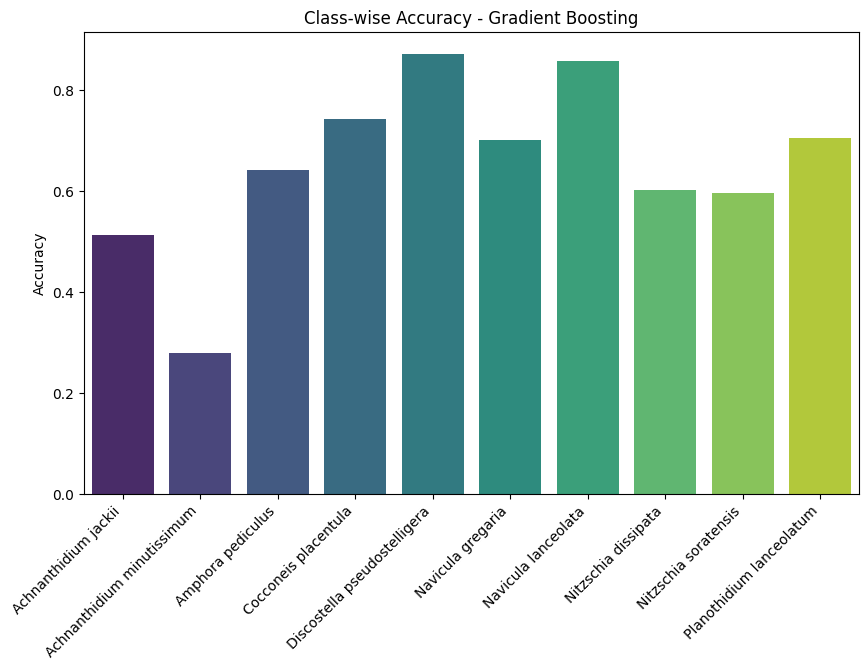

In [8]:
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
class_acc = [report[cls]['recall'] for cls in class_names]

plt.figure(figsize=(10,6))
sns.barplot(x=class_names, y=class_acc, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy - Gradient Boosting")
plt.show()

Explanation:
Plots recall (accuracy per class) to see which species are classified well


Reliability plot

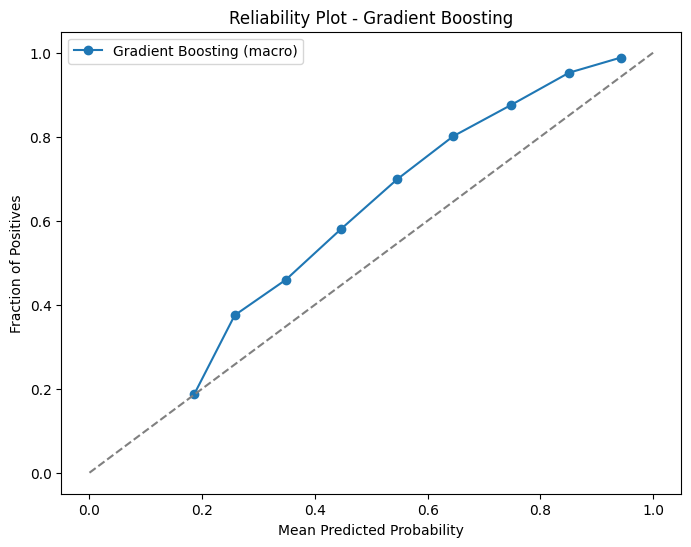

In [9]:
correct = (y_pred == y_test).astype(int)
confidence = np.max(y_prob, axis=1)

prob_true, prob_pred = calibration_curve(correct, confidence, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', label="Gradient Boosting (macro)")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Reliability Plot - Gradient Boosting")
plt.legend()
plt.show()

Explanation:
Shows how well predicted probabilities match actual correctness overall.


In [10]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Gradient Boosting Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Gradient Boosting Accuracy: 0.6473

Classification Report:
                              precision    recall  f1-score   support

        Achnanthidium jackii       0.58      0.51      0.54       575
  Achnanthidium minutissimum       0.42      0.28      0.34       584
           Amphora pediculus       0.61      0.64      0.63       620
        Cocconeis placentula       0.73      0.74      0.74       365
Discostella pseudostelligera       0.84      0.87      0.85       706
           Navicula gregaria       0.66      0.70      0.68       465
         Navicula lanceolata       0.86      0.86      0.86       455
         Nitzschia dissipata       0.66      0.60      0.63       378
        Nitzschia soratensis       0.41      0.60      0.49       411
    Planothidium lanceolatum       0.67      0.70      0.69       389

                    accuracy                           0.65      4948
                   macro avg       0.64      0.65      0.64      4948
                weighted avg 

✅ Workflow Summary
- Trains Gradient Boosting with 200 trees.
- Saves model as gradient_boosting.pkl.
- Evaluates with confusion matrix, ROC, PR curve, confidence distribution, class-wise accuracy, and reliability plot.
- Prints overall accuracy and classification report
